In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/predict-acquire-winner/train.csv
/kaggle/input/predict-acquire-winner/test.csv


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
pd.options.display.max_columns=None

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
train = pd.read_csv('/kaggle/input/predict-acquire-winner/train.csv')
train.head()

,player1,player2,player3,player4,score1,score2,score3,score4,gameID,winning_player
0,7,12,10,6,262,459,406,409,1408990866000,2
1,6,12,10,7,524,419,195,402,1408994459000,1
2,7,10,6,12,308,353,467,497,1408998197000,4
3,12,7,10,6,500,525,256,261,1409002158000,2
4,10,6,23,7,383,375,228,242,1409600757000,1


In [4]:
test = pd.read_csv('/kaggle/input/predict-acquire-winner/test.csv')
test.head()

,player1,player2,player3,player4,gameID
0,16879,13546,26637,22794,1624842388563
1,24647,43,25618,17891,1624842523920
2,16674,16908,273,16468,1624842540568
3,26333,27412,26244,23620,1624842951043
4,16908,43,17891,273,1624843133958


In [5]:
combined = pd.concat([train,test])
combined.head()

,player1,player2,player3,player4,score1,score2,score3,score4,gameID,winning_player
0,7,12,10,6,262.0,459.0,406.0,409.0,1408990866000,2.0
1,6,12,10,7,524.0,419.0,195.0,402.0,1408994459000,1.0
2,7,10,6,12,308.0,353.0,467.0,497.0,1408998197000,4.0
3,12,7,10,6,500.0,525.0,256.0,261.0,1409002158000,2.0
4,10,6,23,7,383.0,375.0,228.0,242.0,1409600757000,1.0


In [6]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 404712 entries, 0 to 121413
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   player1         404712 non-null  int64  
 1   player2         404712 non-null  int64  
 2   player3         404712 non-null  int64  
 3   player4         404712 non-null  int64  
 4   score1          283298 non-null  float64
 5   score2          283298 non-null  float64
 6   score3          283298 non-null  float64
 7   score4          283298 non-null  float64
 8   gameID          404712 non-null  int64  
 9   winning_player  283298 non-null  float64
dtypes: float64(5), int64(5)
memory usage: 34.0 MB


In [7]:
combined.dtypes

player1             int64
player2             int64
player3             int64
player4             int64
score1            float64
score2            float64
score3            float64
score4            float64
gameID              int64
winning_player    float64
dtype: object

In [8]:
combined.describe().T

,count,mean,std,min,25%,50%,75%,max
player1,404712.0,1.115719e+04,9.381059e+03,1.000000e+00,1.736000e+03,9.594000e+03,1.739600e+04,3.355800e+04
player2,404712.0,1.115618e+04,9.395032e+03,1.000000e+00,1.736000e+03,9.594000e+03,1.744800e+04,3.357500e+04
player3,404712.0,1.115345e+04,9.385598e+03,1.000000e+00,1.736000e+03,9.594000e+03,1.739500e+04,3.357500e+04
player4,404712.0,1.113570e+04,9.380920e+03,1.000000e+00,1.736000e+03,9.594000e+03,1.739100e+04,3.357500e+04
score1,283298.0,3.796090e+02,9.850445e+01,4.100000e+01,3.100000e+02,3.770000e+02,4.460000e+02,1.041000e+03
score2,283298.0,3.780491e+02,9.737740e+01,3.300000e+01,3.090000e+02,3.750000e+02,4.430000e+02,9.650000e+02
score3,283298.0,3.722611e+02,9.728963e+01,3.500000e+01,3.030000e+02,3.690000e+02,4.380000e+02,1.127000e+03
score4,283298.0,3.681440e+02,9.734390e+01,3.500000e+01,2.990000e+02,3.650000e+02,4.340000e+02,9.310000e+02
gameID,404712.0,1.575710e+12,7.144655e+10,1.408991e+12,1.519351e+12,1.592855e+12,1.633919e+12,1.679993e+12
winning_player,283298.0,2.424415e+00,1.113571e+00,1.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00


In [9]:
combined.isnull().sum()/len(combined)*100

player1            0.000000
player2            0.000000
player3            0.000000
player4            0.000000
score1            30.000099
score2            30.000099
score3            30.000099
score4            30.000099
gameID             0.000000
winning_player    30.000099
dtype: float64

In [10]:
combined.shape

(404712, 10)

<Axes: >

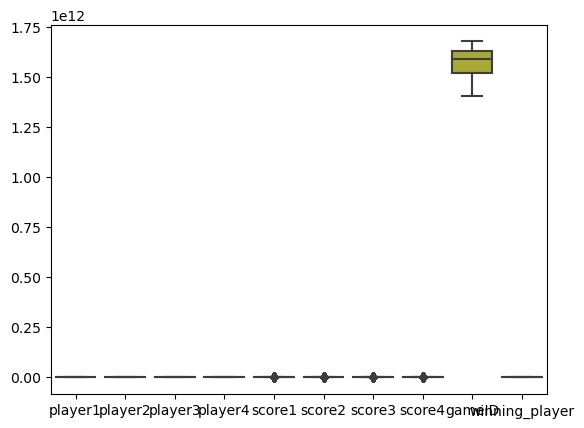

In [11]:
sns.boxplot(combined)

In [12]:
combined.kurt()

player1          -0.862602
player2          -0.867634
player3          -0.858731
player4          -0.855263
score1           -0.108231
score2           -0.113955
score3           -0.120468
score4           -0.136283
gameID           -0.830808
winning_player   -1.342474
dtype: float64

In [13]:
combined.skew()

player1           0.477226
player2           0.477401
player3           0.480304
player4           0.482865
score1            0.187694
score2            0.194565
score3            0.200341
score4            0.195467
gameID           -0.516060
winning_player    0.094451
dtype: float64

<Axes: >

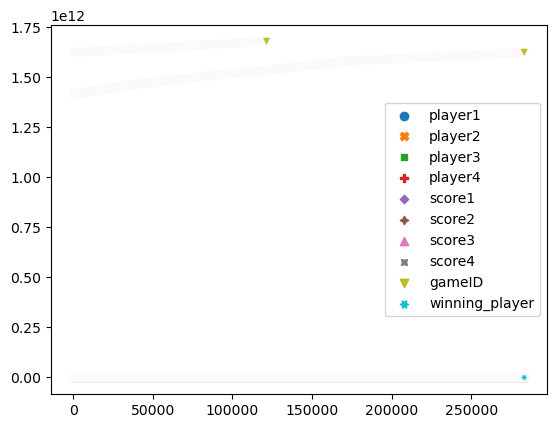

In [14]:
sns.scatterplot(combined)

<Axes: >

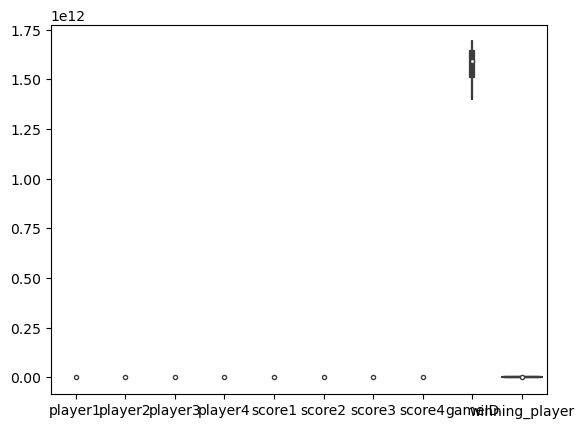

In [15]:
sns.violinplot(combined)

<Axes: >

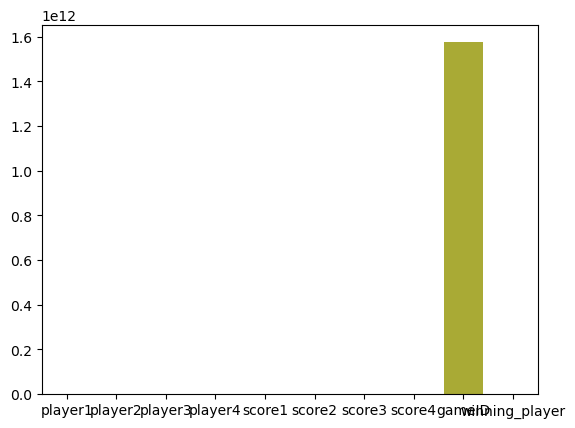

In [16]:
sns.barplot(combined)

<Axes: >

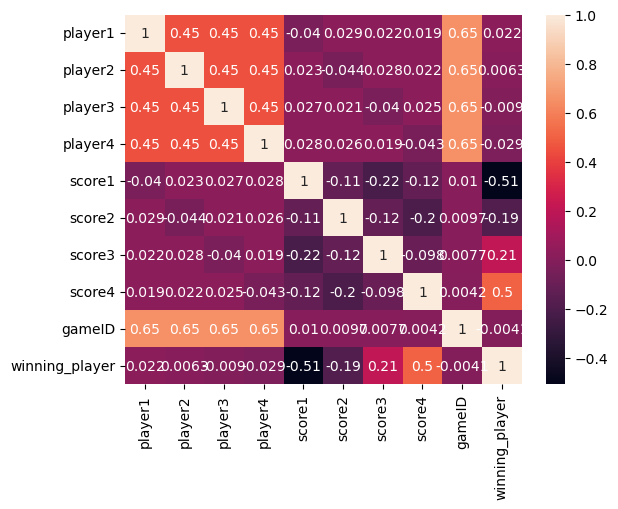

In [17]:
sns.heatmap(combined.corr(),annot=True)

<Axes: ylabel='Density'>

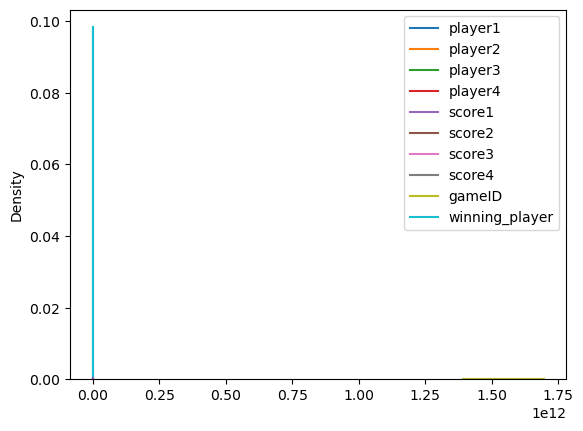

In [18]:
sns.kdeplot(combined)

/opt/conda/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


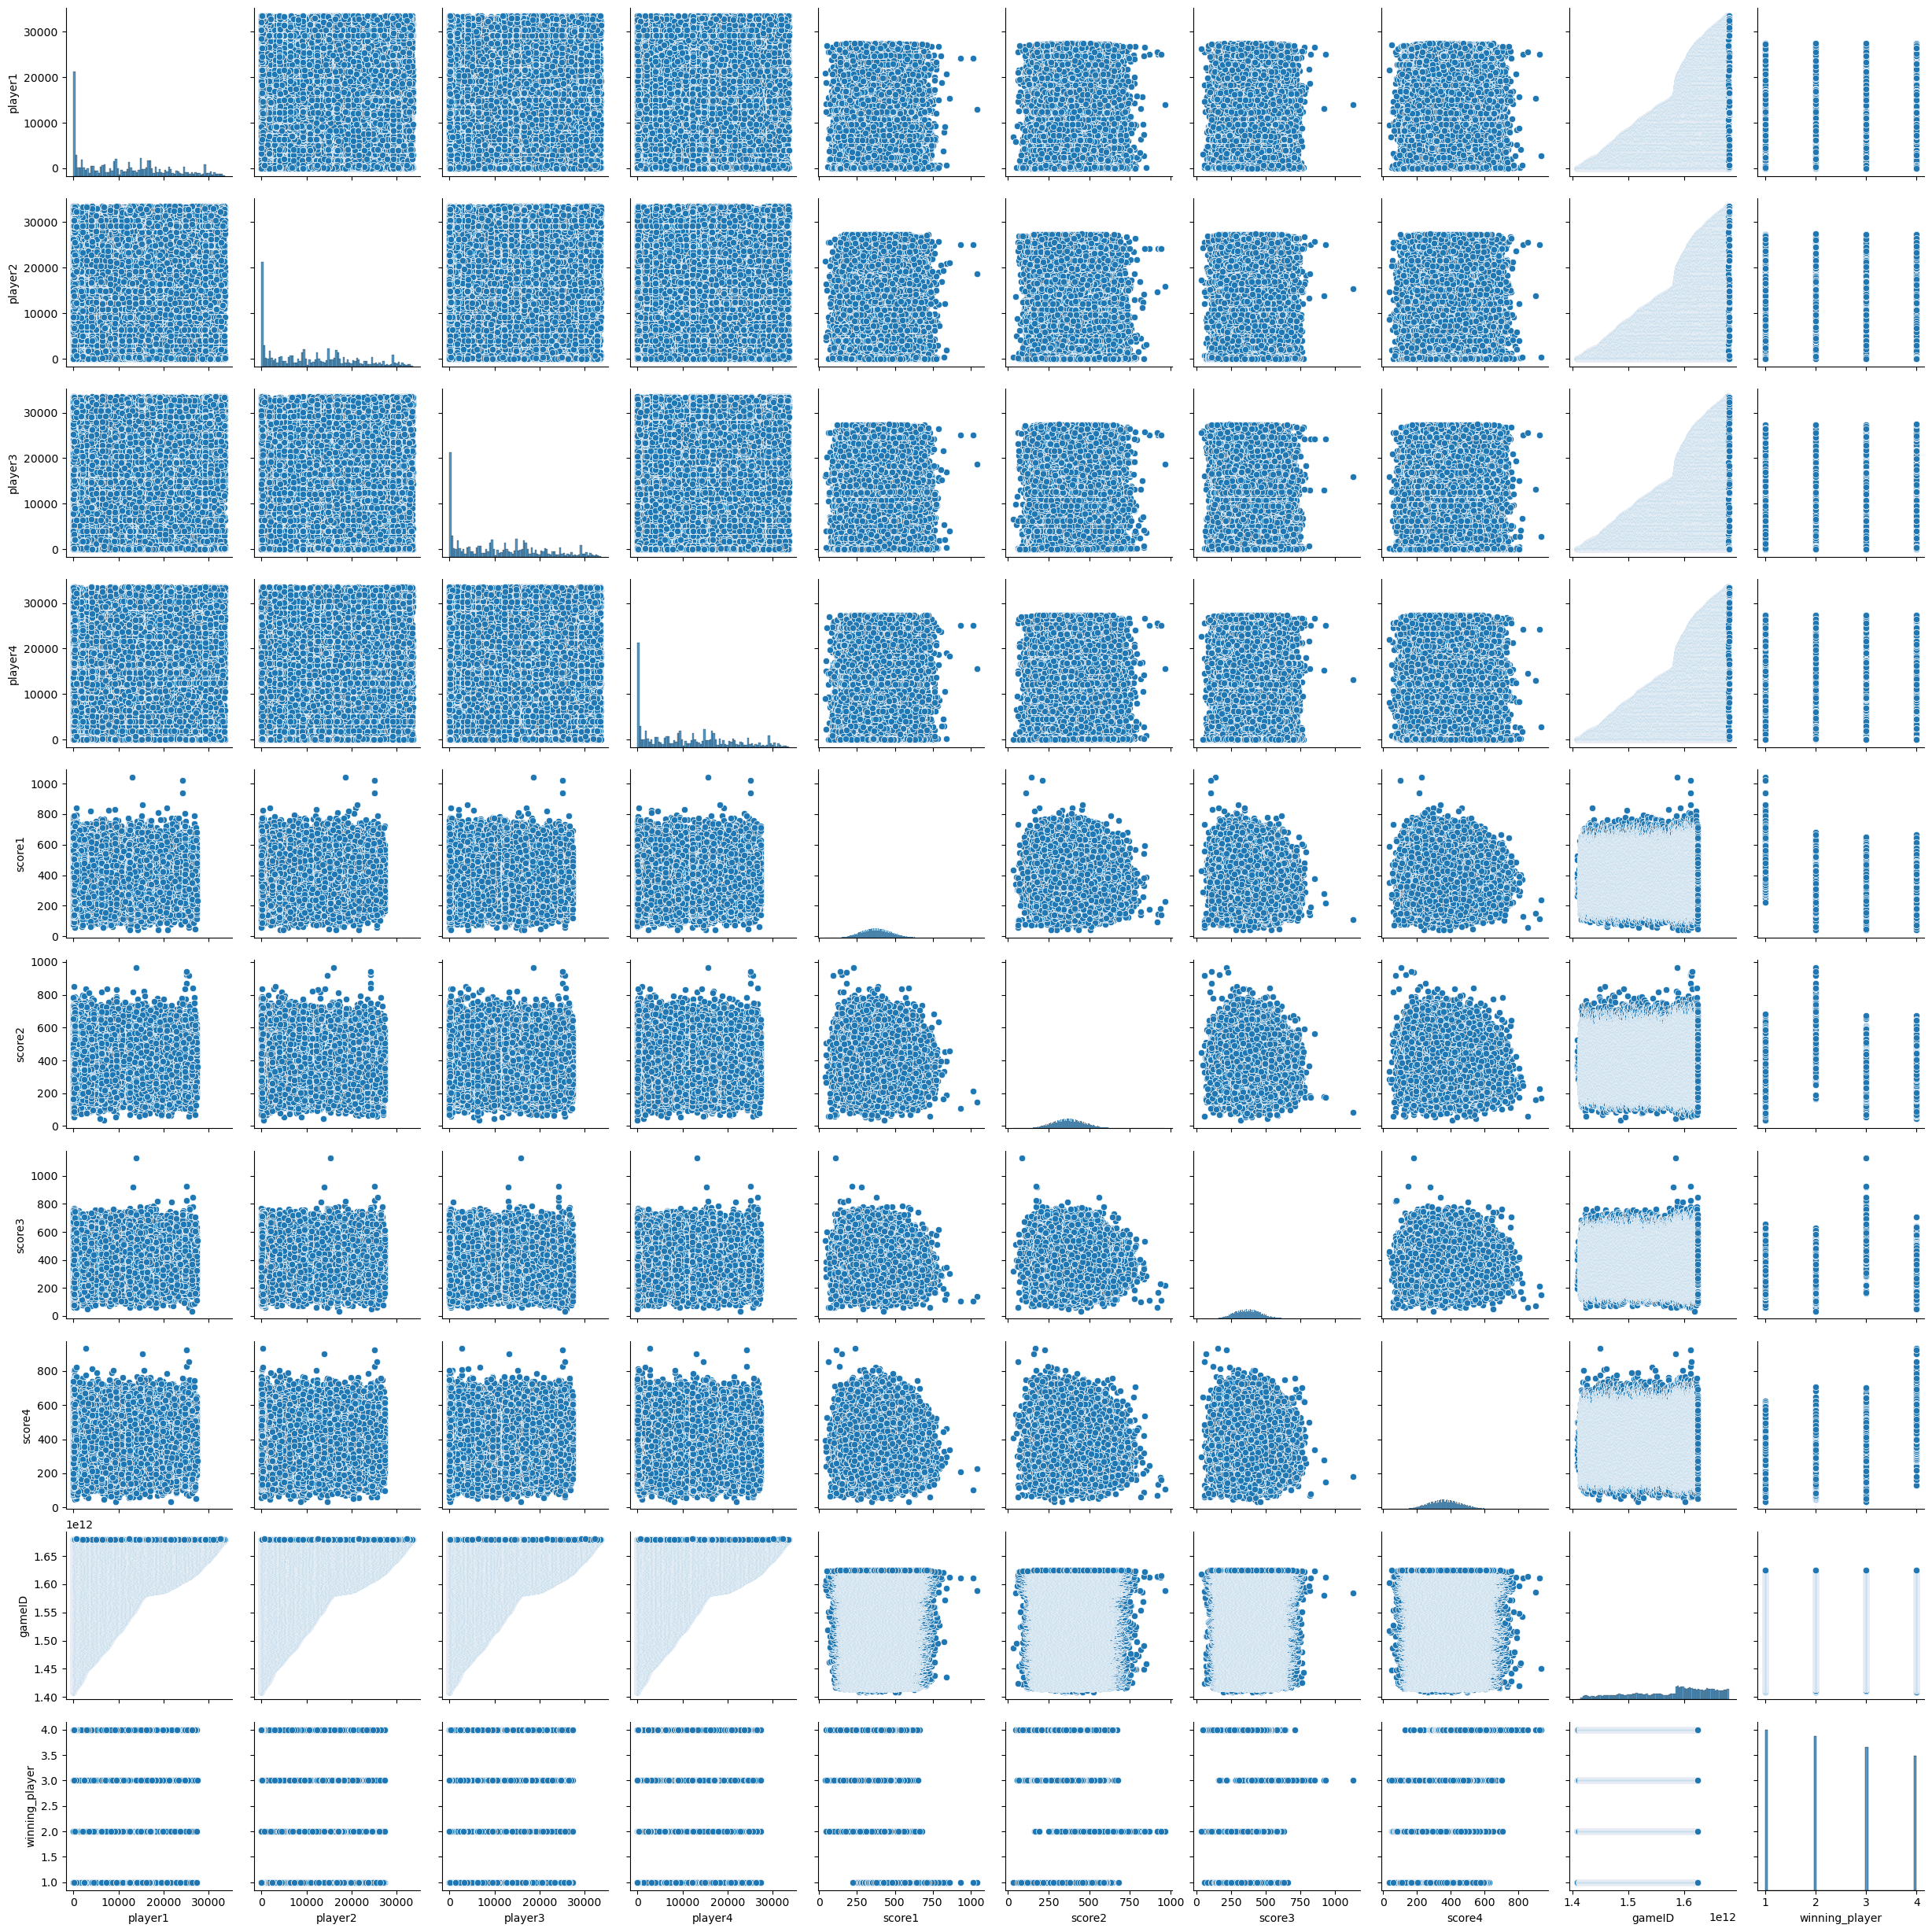

In [19]:
sns.pairplot(combined)

In [20]:
cat_cols = combined.select_dtypes(include='object')

In [21]:
for i in cat_cols:
    print(i)
    print(combined[i].value_counts())
    print('_'*50)

In [22]:
num_cols = combined.select_dtypes(include='number')

In [23]:
for i in num_cols:
    print(i)
    print(combined[i].value_counts())
    print('_'*50)

player1
16       4389
43       4237
9125     4112
2        3737
1736     3457
         ... 
11525       1
11581       1
11576       1
23381       1
33533       1
Name: player1, Length: 8968, dtype: int64
__________________________________________________
player2
16       4383
43       4322
9125     3917
2        3737
1736     3500
         ... 
17710       1
17709       1
17698       1
17516       1
33447       1
Name: player2, Length: 8830, dtype: int64
__________________________________________________
player3
16       4391
43       4193
9125     3955
2        3756
1736     3620
         ... 
23454       1
23453       1
23460       1
20923       1
16800       1
Name: player3, Length: 8944, dtype: int64
__________________________________________________
player4
16       4526
43       4297
9125     4107
2        3874
1736     3588
         ... 
18801       1
11562       1
23460       1
11574       1
16756       1
Name: player4, Length: 8943, dtype: int64
_______________________________

In [24]:
combined['player1']=combined['player1'].map({'Good':2,'Standard':1,'Poor':0})

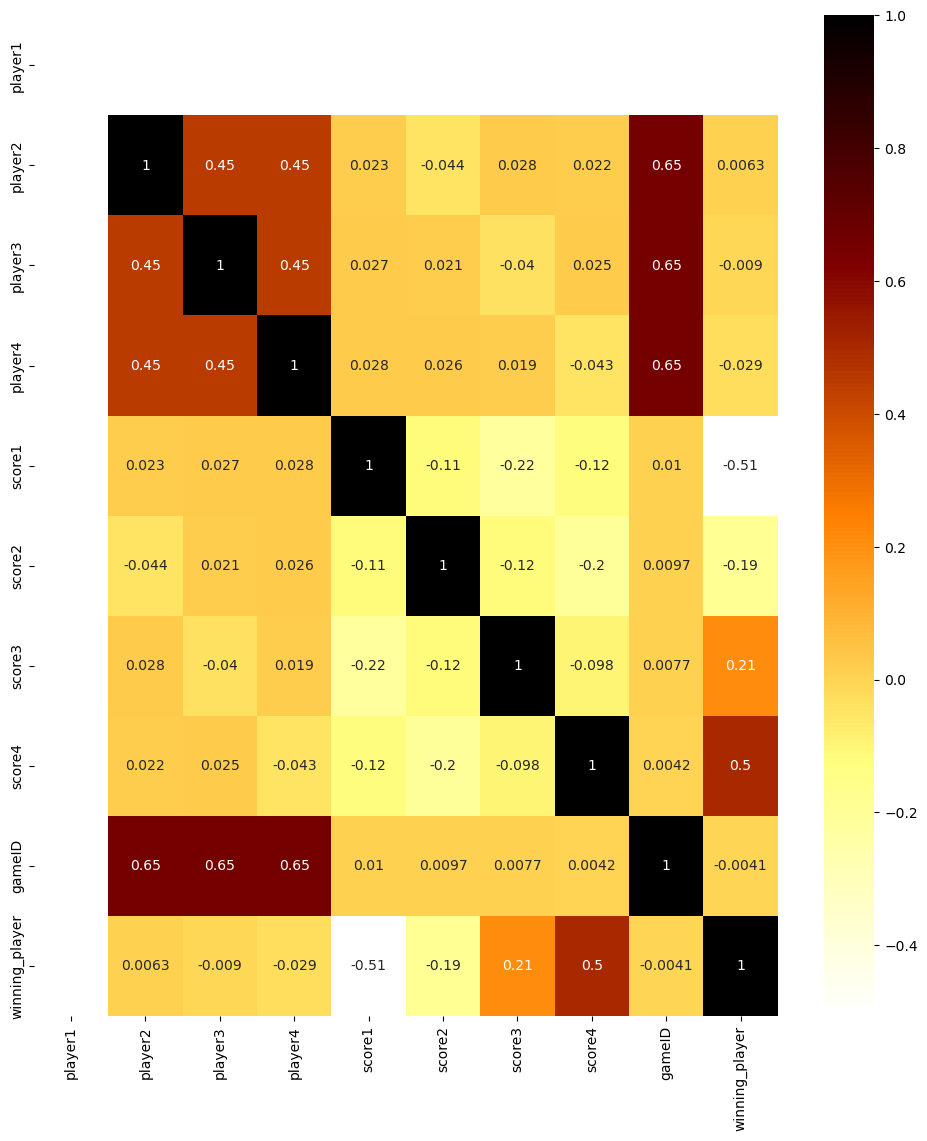

In [25]:
plt.figure(figsize=(12,13))
sns.heatmap(combined.corr(),annot=True,cmap='afmhot_r')
plt.show()

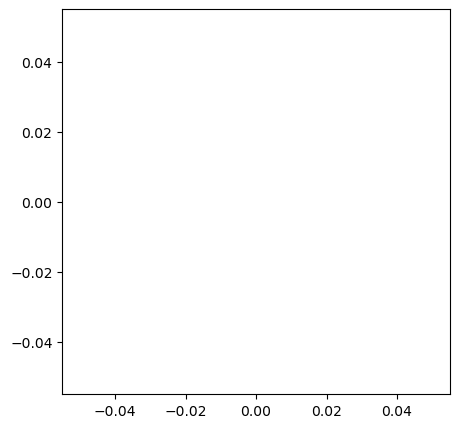

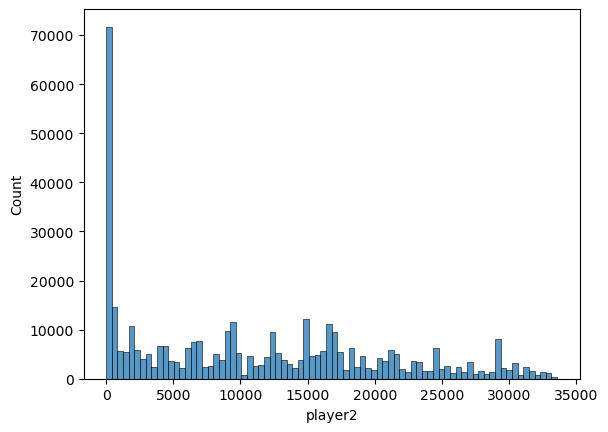

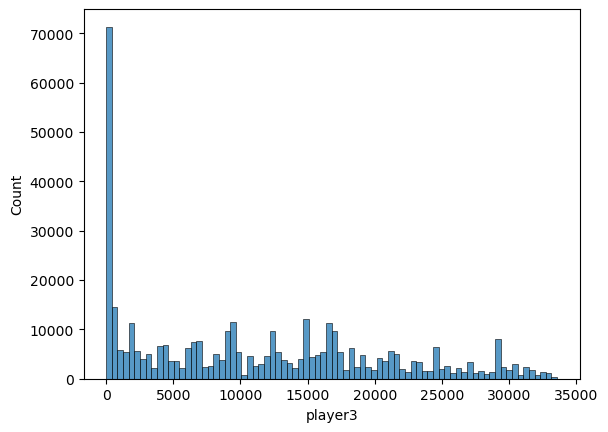

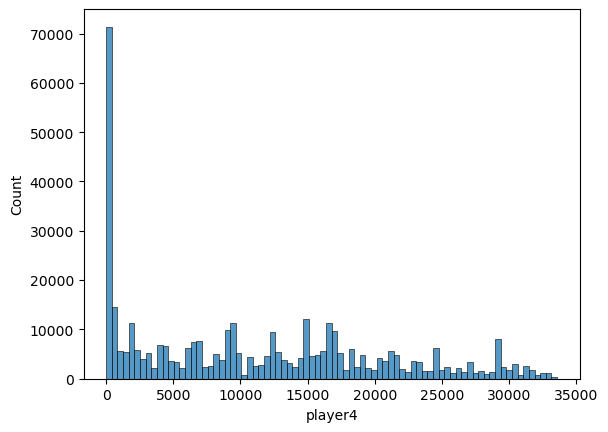

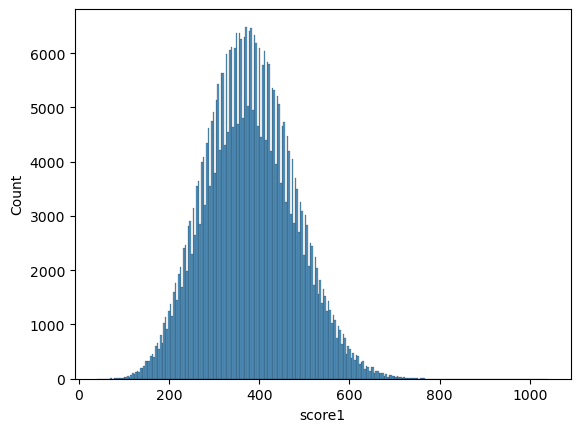

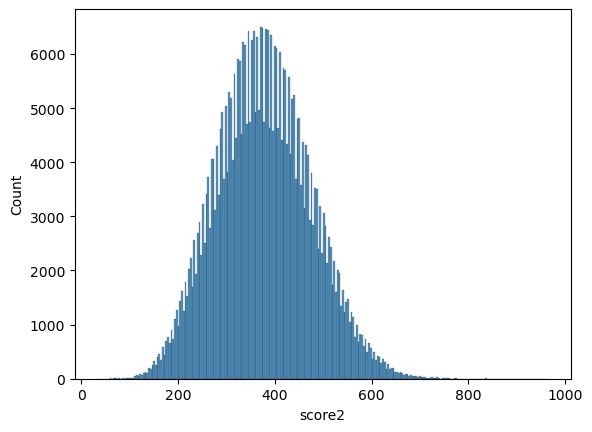

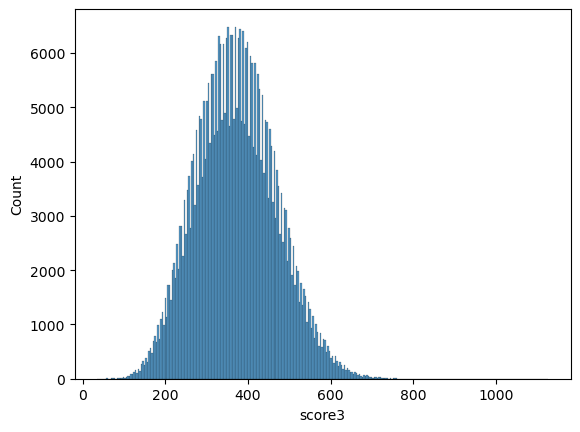

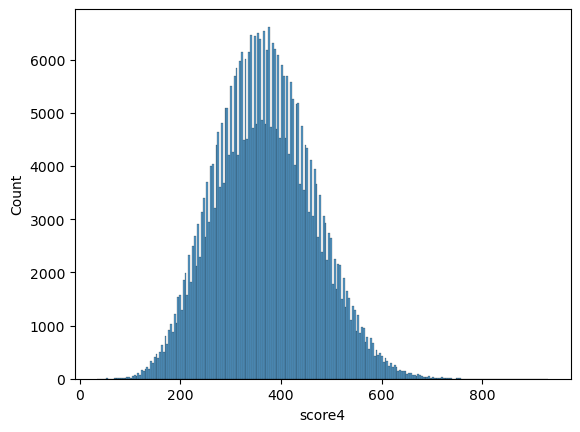

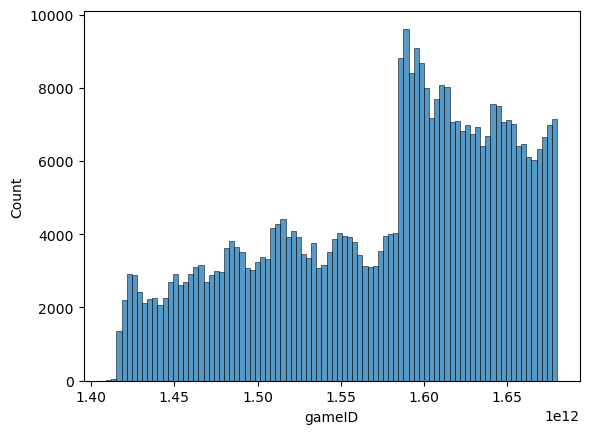

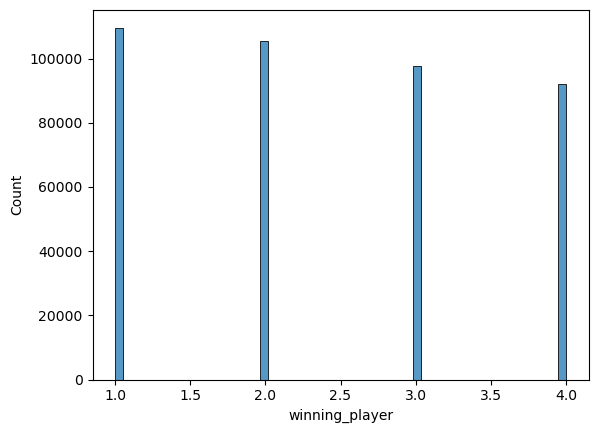

In [26]:
x=1
plt.figure(figsize=(5,5))
for i in num_cols:
    sns.histplot(data=combined,x=i)
    print('\n')
    plt.show()

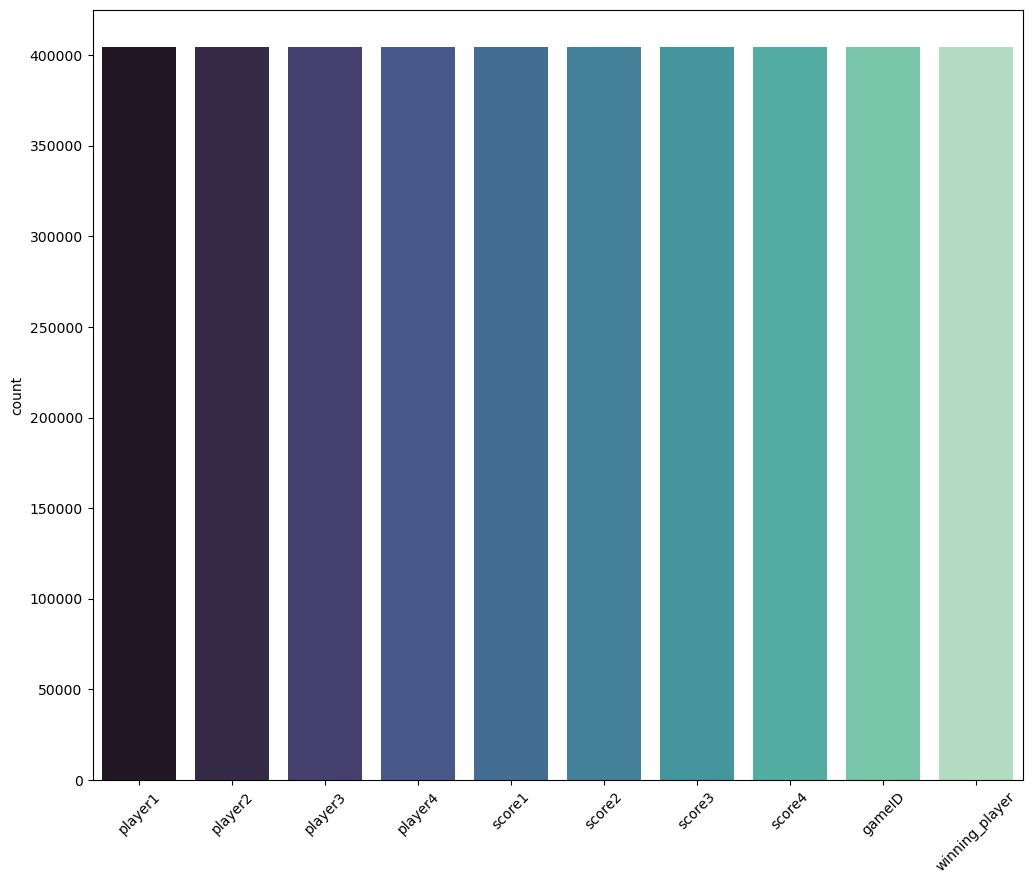

In [27]:
plt.figure(figsize=(12,10))
sns.countplot(data=combined,palette='mako');
plt.xticks(rotation=45);

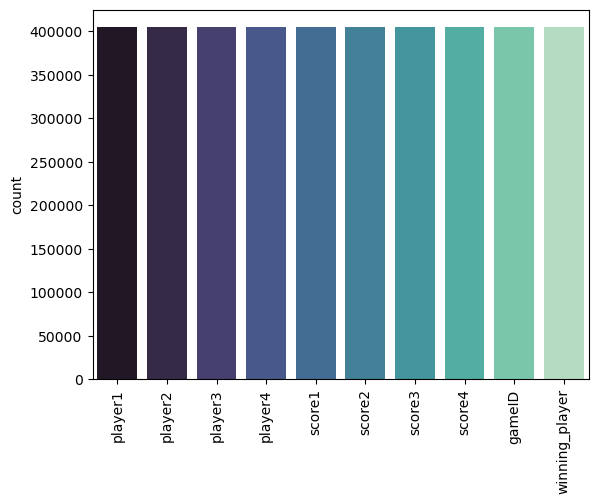

In [28]:
sns.countplot(data=combined,palette='mako');
plt.xticks(rotation=90);

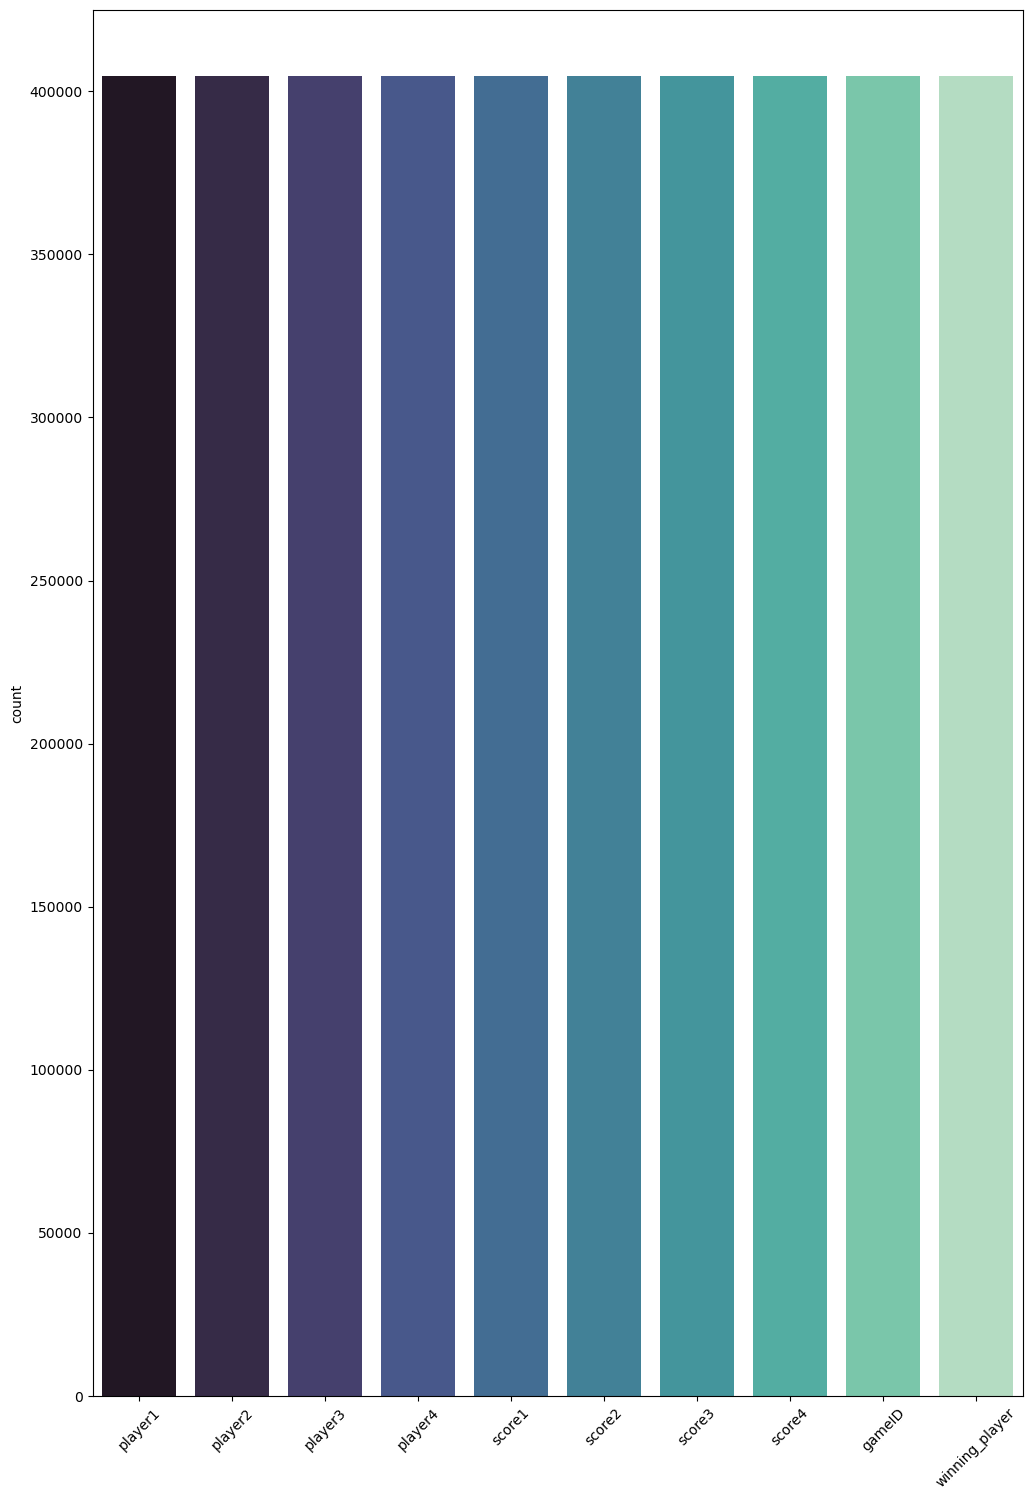

In [29]:
plt.figure(figsize=(12,18))
sns.countplot(data=combined,palette='mako');
plt.xticks(rotation=45);

In [30]:
# Replacing weird value
combined = combined.applymap(lambda x: x if x is np.NaN or not isinstance(x,str)else str(x).strip('_,"')
                            ).replace(['','nan','!@9#%8','#F%$D@*&8'],np.NaN)

In [31]:
combined.head()

,player1,player2,player3,player4,score1,score2,score3,score4,gameID,winning_player
0,NaN,12,10,6,262.0,459.0,406.0,409.0,1408990866000,2.0
1,NaN,12,10,7,524.0,419.0,195.0,402.0,1408994459000,1.0
2,NaN,10,6,12,308.0,353.0,467.0,497.0,1408998197000,4.0
3,NaN,7,10,6,500.0,525.0,256.0,261.0,1409002158000,2.0
4,NaN,6,23,7,383.0,375.0,228.0,242.0,1409600757000,1.0


In [32]:
# Treating type of player2
combined['player1'].value_counts().head(9).index[1:]

Float64Index([], dtype='float64')

In [33]:
## Rebuild type of player2 columns
for i in combined['player1'].value_counts().head(9).index[1:]:
    combined[i]=combined['player1'].int.contains(i)

In [34]:
combined.head()

,player1,player2,player3,player4,score1,score2,score3,score4,gameID,winning_player
0,NaN,12,10,6,262.0,459.0,406.0,409.0,1408990866000,2.0
1,NaN,12,10,7,524.0,419.0,195.0,402.0,1408994459000,1.0
2,NaN,10,6,12,308.0,353.0,467.0,497.0,1408998197000,4.0
3,NaN,7,10,6,500.0,525.0,256.0,261.0,1409002158000,2.0
4,NaN,6,23,7,383.0,375.0,228.0,242.0,1409600757000,1.0


In [35]:
combined.drop('player1',inplace=True,axis=1)

In [36]:
mapping =combined.groupby('player2')['player3'].mean().to_dict()

In [37]:
combined['player3']=combined['player2'].map(mapping)

In [38]:
combined['player3']=round(combined['player3'],0)

In [39]:
combined['player3']=combined['player3'].astype(int)

In [40]:
combined.head()

,player2,player3,player4,score1,score2,score3,score4,gameID,winning_player
0,12,884,6,262.0,459.0,406.0,409.0,1408990866000,2.0
1,12,884,7,524.0,419.0,195.0,402.0,1408994459000,1.0
2,10,179,12,308.0,353.0,467.0,497.0,1408998197000,4.0
3,7,1360,6,500.0,525.0,256.0,261.0,1409002158000,2.0
4,6,678,7,383.0,375.0,228.0,242.0,1409600757000,1.0


In [41]:
combined.isnull().sum()

player2                0
player3                0
player4                0
score1            121414
score2            121414
score3            121414
score4            121414
gameID                 0
winning_player    121414
dtype: int64

In [42]:
combined['player2'].value_counts()

16       4383
43       4322
9125     3917
2        3737
1736     3500
         ... 
17710       1
17709       1
17698       1
17516       1
33447       1
Name: player2, Length: 8830, dtype: int64

In [43]:
# Replacing nm value in 
combined['player2']=combined['player2'].replace({'NM':'Other'})

In [44]:
combined['player2'].value_counts()

16       4383
43       4322
9125     3917
2        3737
1736     3500
         ... 
17710       1
17709       1
17698       1
17516       1
33447       1
Name: player2, Length: 8830, dtype: int64

In [45]:
# Treating null of player2
combined.groupby('player2')['player3'].apply(lambda x:x.fillna(x.mode()[0]))

/tmp/ipykernel_20/664016251.py:2: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  combined.groupby('player2')['player3'].apply(lambda x:x.fillna(x.mode()[0]))


0           884
0         14491
1           884
1          9341
2           179
          ...  
283293    13498
283294    11075
283295    15417
283296    16104
283297    15217
Name: player3, Length: 404712, dtype: int64

In [46]:
cat_cols = combined.select_dtypes(include='object')
num_cols = combined.select_dtypes(include='number')

In [47]:
cat_cols.shape,num_cols.shape

((404712, 0), (404712, 9))

In [48]:
combined.shape

(404712, 9)

In [49]:
combined.head()

,player2,player3,player4,score1,score2,score3,score4,gameID,winning_player
0,12,884,6,262.0,459.0,406.0,409.0,1408990866000,2.0
1,12,884,7,524.0,419.0,195.0,402.0,1408994459000,1.0
2,10,179,12,308.0,353.0,467.0,497.0,1408998197000,4.0
3,7,1360,6,500.0,525.0,256.0,261.0,1409002158000,2.0
4,6,678,7,383.0,375.0,228.0,242.0,1409600757000,1.0


In [50]:
combined['score1']=combined['score1'].map({True:1,False:0,np.nan:0})

In [51]:
combined['score2']=combined['score2'].map({True:1,False:0,np.nan:0})
combined['score3']=combined['score3'].map({True:1,False:0,np.nan:0})
combined['score4']=combined['score4'].map({True:1,False:0,np.nan:0})

In [52]:
combined.isnull().sum()

player2                0
player3                0
player4                0
score1            283298
score2            283298
score3            283298
score4            283298
gameID                 0
winning_player    121414
dtype: int64

In [53]:
cat_cols

""
0
1
2
3
4
...
121409
121410
121411
121412


In [54]:
plt.figure(figsize=(15,20))
iterator=1
for i in cat_cols:
    plt.subplot(4,2,iterator)
    sns.countplot(combined[i],palette='mako')
    iterator+=1
    plt.xticks(rotation=90)
plt.tight_layout()

<Figure size 1500x2000 with 0 Axes>

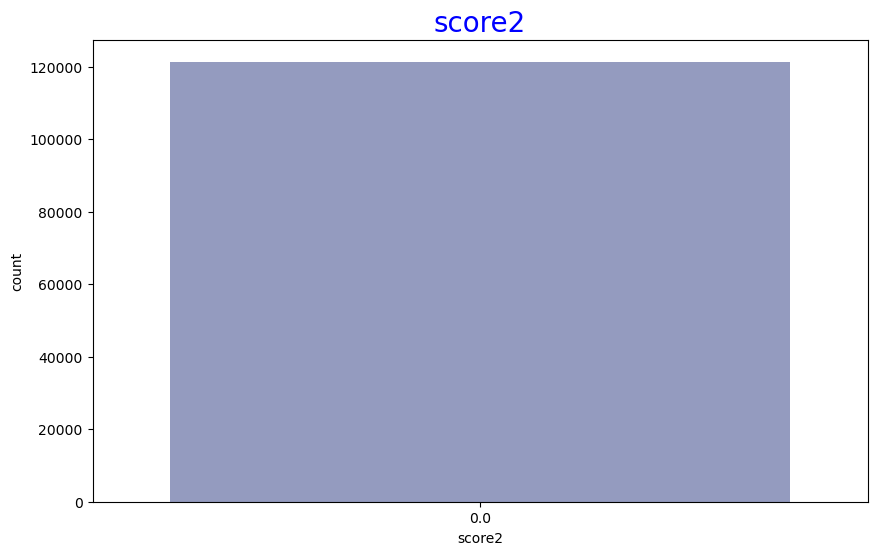

In [55]:
plt.figure(figsize=(10,6))
sns.countplot(data=combined,x='score2',palette='BuPu_r')
plt.title('score2',size=20,color='Blue')
plt.show()

In [56]:
combined['score3'].value_counts(normalize=True)*100

0.0    100.0
Name: score3, dtype: float64

In [57]:
combined['gameID'].unique()

array([1408990866000, 1408994459000, 1408998197000, ..., 1679990274253,
       1679991086238, 1679992870208])

In [58]:
combined['gameID']=combined['gameID'].map({'Good':2,'Standard':1,'Poor':0})

In [59]:
combined['winning_player']=combined['winning_player'].map({'Large':2,'Medium':1,'Small':0})

In [60]:
train.shape[0]

283298

In [61]:
new_train=combined.iloc[0:train.shape[0],:]

In [62]:
new_test=combined.iloc[train.shape[0]:,:]

In [63]:
train.shape,new_train.shape,test.shape,new_test.shape

((283298, 10), (283298, 9), (121414, 5), (121414, 9))

In [64]:
import scipy.stats as stats

In [65]:
sig_num=[]
for i in num_cols:
    zero=new_train.loc[new_train['winning_player']==0,i]
    one=new_train.loc[new_train['winning_player']==1,i]
    two=new_train.loc[new_train['winning_player']==2,i]
    teststat,pval=stats.f_oneway(zero,one,two)
    if pval<0.05:
        sig_num.append(i)
        print(i)

/opt/conda/lib/python3.10/site-packages/scipy/stats/stats.py:3621: F_onewayBadInputSizesWarning: at least one input has length 0
  warnings.warn(F_onewayBadInputSizesWarning('at least one input '


In [66]:
sig_cat=[]
for i in cat_cols:
    a=pd.crosstab(new_train[i],new_train['winning_player'])
    tstat,pval,dof,freq=stats.chi2_contingency(a)
    if pval<0.05:
        sig_cat.append(i)
        print(i)

In [67]:
train_new=new_train.loc[:,sig_cat+sig_num]

In [68]:
test_new=new_test.loc[:,sig_cat+sig_num]

In [69]:
train_new

""
0
1
2
3
4
...
283293
283294
283295
283296


In [70]:
test_new

""
0
1
2
3
4
...
121409
121410
121411
121412


In [71]:
# Scailng the col

In [72]:
scaling =[]

In [73]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [74]:
for i in scaling:
    train_new.loc[:,i]=scaler.fit_transform(pd.DataFrame(train_new.loc[:,i]))
    test_new.loc[:,i]=scaler.transform(pd.DataFrame(test_new.loc[:,i]))

In [75]:
train_new

""
0
1
2
3
4
...
283293
283294
283295
283296
